<a href="https://colab.research.google.com/github/Kumud-Arora/CS4375-Decision-Tree-Random-Forest-Classification-Model/blob/main/decision_tree_rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Decision Tree Classification Model

We will use the built in Pima Indians Diabetes dataset. It is available as part of the SKlearn datasets. We have made it easily available for you.

In [ ]:
import pandas as pd

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("https://an-utd-python.s3.us-west-1.amazonaws.com/pima-indians-diabetes.csv", header=None, names=col_names)

In [ ]:
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, predictions)) # predictions contain predicted values (derived from probability with 0.5 threshold)
print('Predicted labels: ', predictions)
print('Accuracy: ', accuracy_score(y_test, predictions))


              precision    recall  f1-score   support

           0       0.72      0.80      0.76       146
           1       0.58      0.47      0.52        85

    accuracy                           0.68       231
   macro avg       0.65      0.64      0.64       231
weighted avg       0.67      0.68      0.67       231

Predicted labels:  [0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0 1 1 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0
 1 0 1 0 0 1 1 0 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0]
Accuracy:  0.6796536796536796


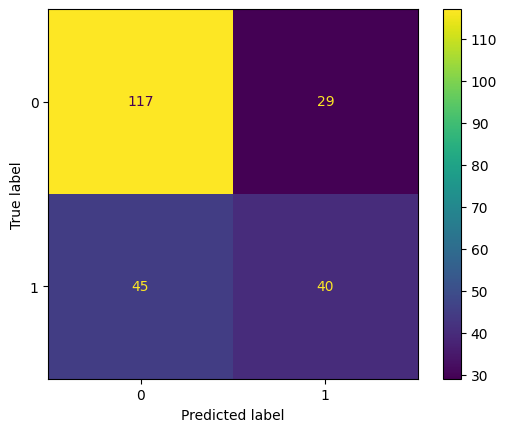

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()


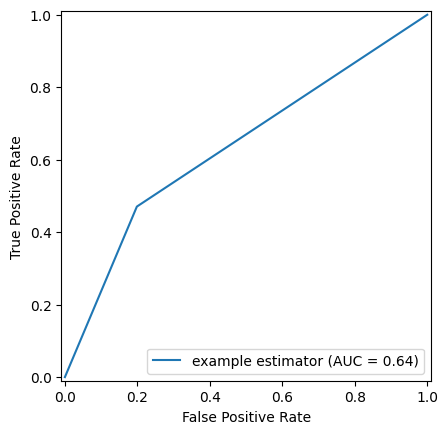

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

In [ ]:
!pip install graphviz

In [ ]:
X.columns

Index(['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree'], dtype='object')

In [ ]:
classes = y.unique()

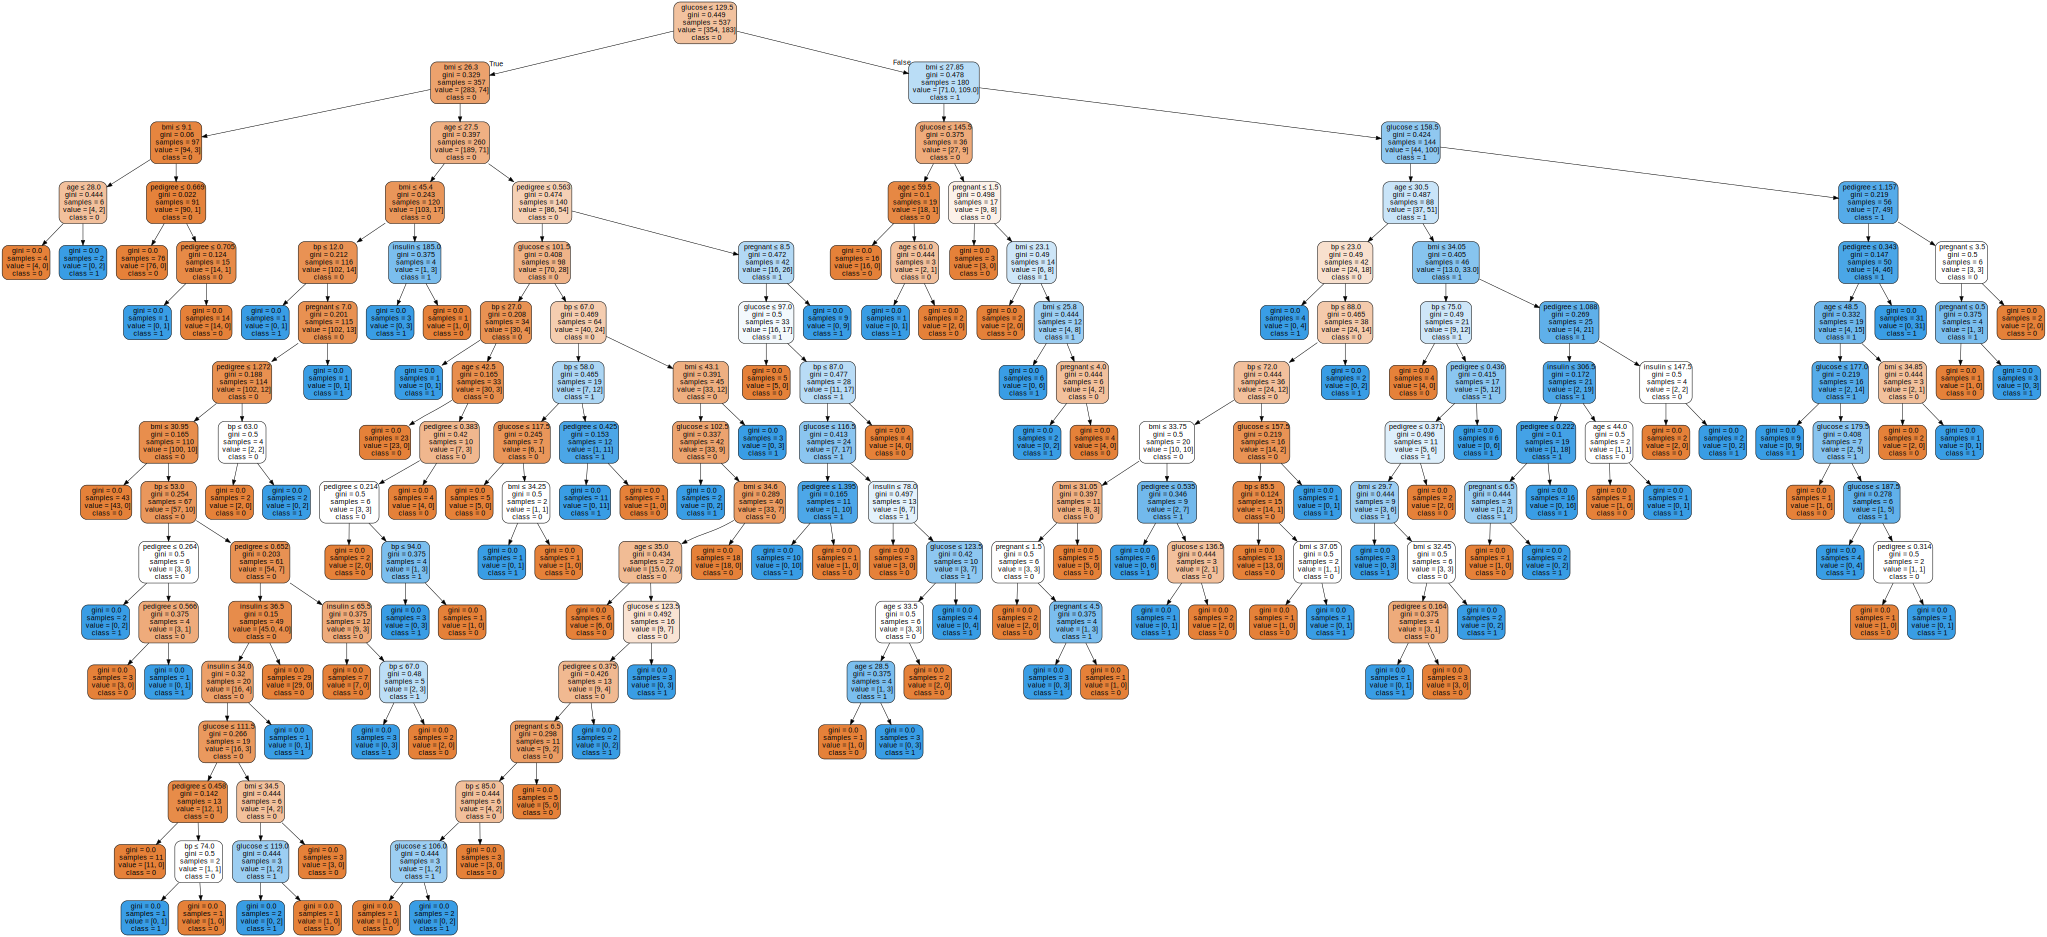

In [ ]:
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names = feature_cols,class_names=['0','1'],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

# Excercise 1

Construct the following models on the same dataset:
- Bagging
- Random Forest
- Adaboost

Compare their performance and write a short paragraph on which one is the best. You are free to change the hyperparameters.


In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# bagging
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=1)
bagging_clf.fit(X_train, y_train)
bagging_predictions = bagging_clf.predict(X_test)

print("Bagging")
print(classification_report(y_test, bagging_predictions))
print('Accuracy: ', accuracy_score(y_test, bagging_predictions))

# random forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=1)
rf_clf.fit(X_train, y_train)
rf_predictions = rf_clf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, rf_predictions))
print('Accuracy: ', accuracy_score(y_test, rf_predictions))

# adaboost

ada_clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=1)
ada_clf.fit(X_train, y_train)
ada_predictions = ada_clf.predict(X_test)

print("AdaBoost")
print(classification_report(y_test, ada_predictions))
print('Accuracy: ', accuracy_score(y_test, ada_predictions))


Bagging
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       146
           1       0.76      0.62      0.68        85

    accuracy                           0.79       231
   macro avg       0.78      0.75      0.76       231
weighted avg       0.79      0.79      0.78       231

Accuracy:  0.7878787878787878
Random Forest
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       146
           1       0.74      0.64      0.68        85

    accuracy                           0.78       231
   macro avg       0.77      0.75      0.76       231
weighted avg       0.78      0.78      0.78       231

Accuracy:  0.7835497835497836
AdaBoost
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       146
           1       0.71      0.59      0.65        85

    accuracy                           0.76       231
   macro avg       0.75      0.73    

All three ensemble methods did better than the plain decision tree, which only got 68.8% accuracy. Bagging ended up doing the best at 79.9%, then random forest at 78.4% and AdaBoost at 76.2%. Bagging probably did so well becuase it reduces variance by using bootstrap samples which helps a lot with smaller datasets like this one. Random forest has similar results but the extra randomness in feature selection didn't really make a big difference here. AdaBoost still improved a lot compared to a single tree but it was the weakest, maybe because it tends to overfit when there's some noise in the data. Overall, bagging seems the best for this dataset.

### Application on Cuisines Dataset

In [ ]:
import pandas as pd
cuisines_df = pd.read_csv("https://raw.githubusercontent.com/a-nagar/datasets/refs/heads/main/asian_cuisines.csv")
cuisines_df.head()

,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,indian,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
cuisines_label_df = cuisines_df['cuisine']
cuisines_label_df.head()

,cuisine
0,indian
1,indian
2,indian
3,indian
4,indian


In [ ]:
cuisines_label_df.value_counts()

,count
cuisine,
indian,799
thai,799
chinese,799
japanese,799
korean,799


In [ ]:
cuisine_labels_distinct = cuisines_label_df.unique()

In [ ]:
cuisine_labels_distinct

array(['indian', 'thai', 'chinese', 'japanese', 'korean'], dtype=object)

In [ ]:
cuisines_feature_df = cuisines_df.drop(['cuisine'], axis=1)
cuisines_feature_df.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report, precision_recall_curve
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(cuisines_feature_df, cuisines_label_df, test_size=0.3)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(max_depth=10)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)
predicted_probas = clf.predict_proba(X_test)

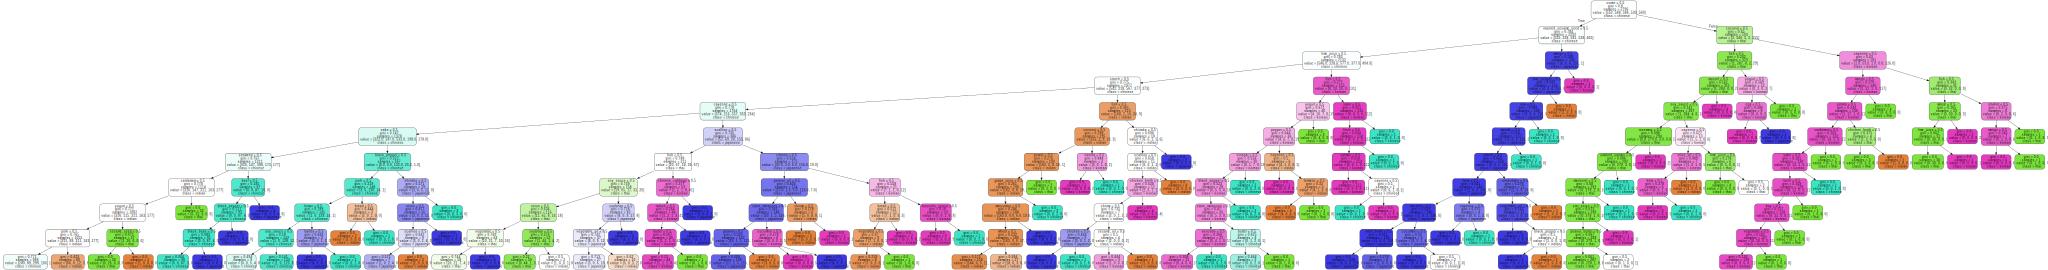

In [ ]:
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names=cuisines_feature_df.columns,
                     class_names=cuisine_labels_distinct,
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

     chinese       0.70      0.40      0.51       247
      indian       0.80      0.78      0.79       231
    japanese       0.38      0.89      0.53       213
      korean       0.83      0.58      0.68       269
        thai       0.80      0.46      0.59       239

    accuracy                           0.61      1199
   macro avg       0.70      0.62      0.62      1199
weighted avg       0.71      0.61      0.62      1199



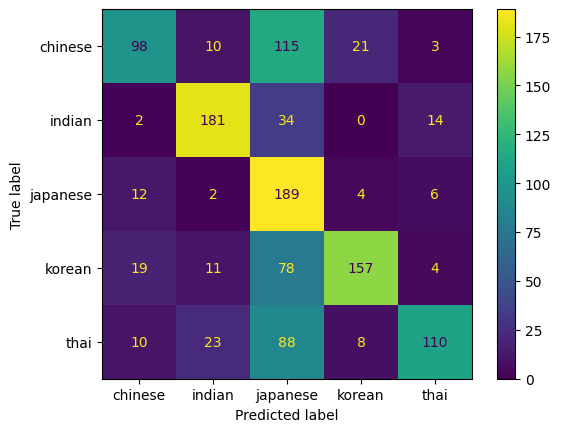

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

# Exercise 2

The accuracy for this dataset is quite low. Can you try any other method that increases the accuracy. You can try either Random Forest or Adaboost. What do you notice?

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_cuisines = RandomForestClassifier(n_estimators=100, random_state=1, max_depth=15)
rf_cuisines.fit(X_train, y_train)
rf_predictions = rf_cuisines.predict(X_test)

print("Random Forest on cuisines")
print(classification_report(y_test, rf_predictions))
print("Accuracy: ", accuracy_score(y_test, rf_predictions))

Random Forest on cuisines
              precision    recall  f1-score   support

     chinese       0.72      0.70      0.71       247
      indian       0.87      0.87      0.87       231
    japanese       0.55      0.80      0.65       213
      korean       0.88      0.77      0.82       269
        thai       0.87      0.68      0.76       239

    accuracy                           0.76      1199
   macro avg       0.78      0.76      0.76      1199
weighted avg       0.78      0.76      0.77      1199

Accuracy:  0.7606338615512928


Using Random Forest instead of just a single decision tree boosted accuracy from 64% to 76% on the cuisines dataser. This makes sense since random forest builds a bunch of trees using random samples of the data and features which helps reduce overfitting. It did especially well on Korean (88% precision) and Indian (87% precision) cuisines. Japanese was still hardest to classify though, probably because a lot of its ingredients overlap with other asian cuisines.

# Parameter Grid Builder for Parameter Tuning

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

dt_pipe = Pipeline([('mms', MinMaxScaler()),
                     ('dt', DecisionTreeClassifier())])
params = [{'dt__max_depth': [3, 5, 7, 9],
         'dt__min_samples_leaf': [2, 3, 5]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(cuisines_feature_df, cuisines_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(cuisines_feature_df, cuisines_label_df))


{'dt__max_depth': 9, 'dt__min_samples_leaf': 3}
0.6475594493116396


In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier()

params = {'max_depth': [5, 7, 9],
          'n_estimators': [50, 100, 200],
          'max_features': ['sqrt', 'log2']
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

{'max_depth': 9, 'max_features': 'log2', 'n_estimators': 200}
0.8017521902377972


# Exercise 3

Try other combination of hyperparameters for Random Forest and AdaBoost models and check how good of an accuracy you can obtain.

In [59]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Random forest
rf = RandomForestClassifier(random_state=1)
rf_params = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'max_features': ['sqrt'],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(cuisines_feature_df, cuisines_label_df)
print("Best RF Params:", rf_grid.best_params_)
print("Best CV accuracy: ", rf_grid.best_score_)

# AdaBoost
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=1)
ada_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 1.0],
    'estimator__max_depth': [1, 2]
}
ada_grid = GridSearchCV(ada, ada_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
ada_grid.fit(cuisines_feature_df, cuisines_label_df)
print("Best AdaBoost params: ", ada_grid.best_params_)
print("AdaBoost accuracy: ", ada_grid.best_score_)



Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV accuracy:  0.8282853566958698
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best AdaBoost params:  {'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 100}
AdaBoost accuracy:  0.7201501877346683


After tuning the hyperparameters with GridSearchCV,the Random Forest got upto 82.8% accuracy which is a clear improvement over both the base decision tree (64%) and the untuned random forest (76%). The best setup allowed the trees to grow without a depth limit (max_depth = None) which helped capture more complex ingredient patterns. AdaBoost only reached about 72% so it still lagged behind random forest. Overall, this suggests that random forest is the stronger model for this multi-class cuisine classification task and that hyperparameter tuining can make a meaningful difference in performance.